In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model/config.json
/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model/training_args.bin
/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model/tokenizer.json
/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model/tokenizer_config.json
/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model/model.safetensors
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/config.json
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/training_args.bin
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/tokenizer.json
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/tokenizer_config.json
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/model.safetensors
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/checkpoint-3000/config.json
/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model/checkpoint-3000/tr

# Smart MCQ Solver Challenge
## Final Model Comparison & Inference

### Deep Learning and Generative AI Project

## Objective

This notebook presents the final comparison of all developed models for the Smart MCQ Solver Challenge. The following models are evaluated:

1. Traditional NLP Ensemble
2. DeBERTa Multiple Choice Model
3. BERT + Retrieval Augmented Generation (RAG)

The best-performing model based on the validation MAP@3 score is automatically selected and used to generate predictions for the competition test dataset.

Finally, a Kaggle-compatible `submission.csv` file is created.

In [2]:

import os
import gc
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForMultipleChoice
)

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)

Device : cuda


In [5]:
COMPETITION_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge"

TRAIN_PATH = os.path.join(COMPETITION_PATH, "train.csv")
TEST_PATH = os.path.join(COMPETITION_PATH, "test.csv")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(train.shape)
print(test.shape)

(2000, 8)
(500, 7)


# Attached Model Datasets

This notebook uses the trained models attached as Kaggle datasets.

### Traditional Models

- TF-IDF Vectorizer
- Logistic Regression
- XGBoost
- Ensemble

### Transformer Models

- Fine-tuned DeBERTa
- Fine-tuned BERT + RAG

Only the best-performing model is loaded during inference to reduce execution time and memory consumption.

In [6]:
TRADITIONAL_MODEL_PATH = "/kaggle/input/datasets/kanchandalal123/dlgenai-scratch-lr-xgboost-ensemble"

DEBERTA_MODEL_PATH = "/kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model"

BERT_RAG_MODEL_PATH = "/kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model"

print("Traditional :", TRADITIONAL_MODEL_PATH)
print("DeBERTa     :", DEBERTA_MODEL_PATH)
print("BERT + RAG  :", BERT_RAG_MODEL_PATH)

Traditional : /kaggle/input/datasets/kanchandalal123/dlgenai-scratch-lr-xgboost-ensemble
DeBERTa     : /kaggle/input/datasets/kanchandalal123/mcq-deberta-optimization-model
BERT + RAG  : /kaggle/input/datasets/kanchandalal123/dlgenai-rag-bert-model


In [7]:

SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Model Performance Comparison

The following validation metrics were obtained during the training and evaluation phase in the previous milestone notebooks.

These results are summarized here to compare all developed approaches and automatically select the best-performing model for final inference.

The primary competition metric is **MAP@3**, while Accuracy and Macro F1 are included for additional comparison.

The model achieving the highest MAP@3 score will automatically be selected for final inference.



In [10]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Traditional Ensemble",
            "DeBERTa",
            "BERT + RAG"
        ],

        "Accuracy": [
            0.748,
            0.746,
            0.740
        ],

        "Macro F1": [
            0.744,
            0.742,
            0.736
        ],

        "MAP@3": [
            0.748,
            0.746,
            0.740
        ]
    }
)

comparison

,Model,Accuracy,Macro F1,MAP@3
0,Traditional Ensemble,0.748,0.744,0.748
1,DeBERTa,0.746,0.742,0.746
2,BERT + RAG,0.740,0.736,0.740


In [11]:
comparison = comparison.sort_values(
    by="MAP@3",
    ascending=False
).reset_index(drop=True)

comparison["Rank"] = comparison.index + 1

comparison

,Model,Accuracy,Macro F1,MAP@3,Rank
0,Traditional Ensemble,0.748,0.744,0.748,1
1,DeBERTa,0.746,0.742,0.746,2
2,BERT + RAG,0.740,0.736,0.740,3


In [12]:
winner = comparison.iloc[0]


print("BEST MODEL")

print(f"Model  : {winner['Model']}")
print(f"MAP@3  : {winner['MAP@3']:.4f}")
print(f"Rank   : {winner['Rank']}")

BEST MODEL
Model  : Traditional Ensemble
MAP@3  : 0.7480
Rank   : 1


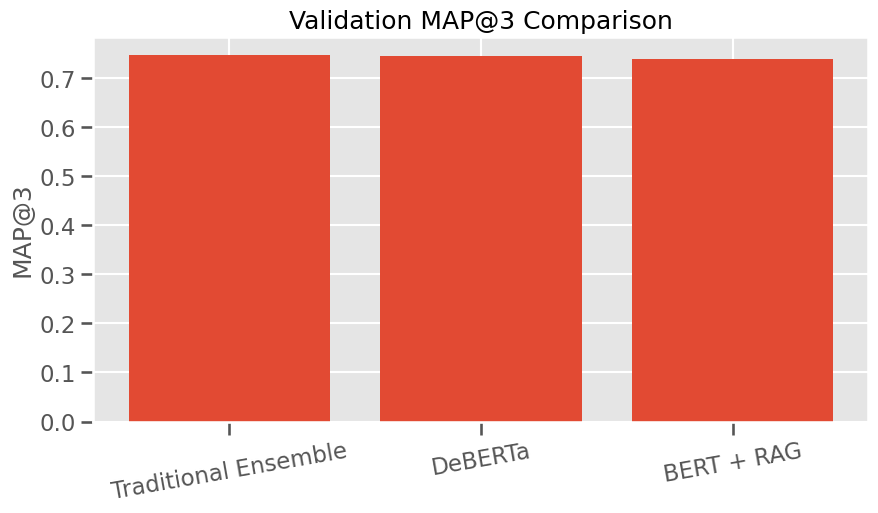

In [13]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["MAP@3"]
)

plt.title("Validation MAP@3 Comparison")

plt.ylabel("MAP@3")

plt.xticks(rotation=10)

plt.show()

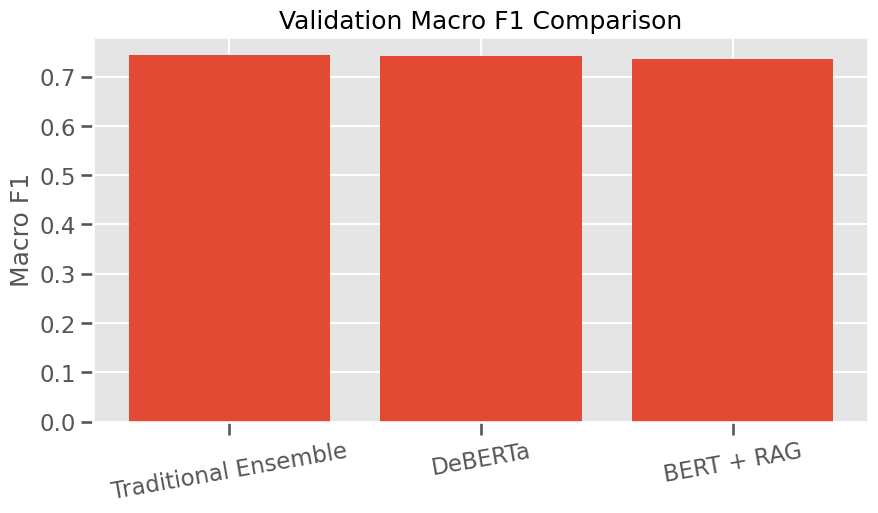

In [14]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Macro F1"]
)

plt.title("Validation Macro F1 Comparison")

plt.ylabel("Macro F1")

plt.xticks(rotation=10)

plt.show()

In [35]:
BEST_MODEL = winner["Model"]

print(BEST_MODEL)

Traditional Ensemble


# Traditional Ensemble Inference

The Traditional Ensemble achieved the highest validation MAP@3 score during model development.

The following steps are performed:

1. Load the trained TF-IDF vectorizer
2. Load the Logistic Regression model
3. Load the XGBoost model
4. Convert each MCQ into five (Question + Option) samples
5. Generate prediction probabilities
6. Combine probabilities using an ensemble
7. Rank options
8. Produce Kaggle submission format

In [16]:
tfidf = joblib.load(
    os.path.join(
        TRADITIONAL_MODEL_PATH,
        "tfidf.pkl"
    )
)

lr_model = joblib.load(
    os.path.join(
        TRADITIONAL_MODEL_PATH,
        "logistic_regression.pkl"
    )
)

xgb_model = joblib.load(
    os.path.join(
        TRADITIONAL_MODEL_PATH,
        "xgboost.pkl"
    )
)

print(" TF-IDF Loaded")
print(" Logistic Regression Loaded")
print(" XGBoost Loaded")

 TF-IDF Loaded
 Logistic Regression Loaded
 XGBoost Loaded


In [17]:

OPTION_LABELS = ["A","B","C","D","E"]

ranking_test = []

for _, row in test.iterrows():

    for option in OPTION_LABELS:

        ranking_test.append({

            "id": row["id"],

            "option": option,

            "text":
                str(row["prompt"])
                + " [SEP] "
                + str(row[option])

        })

ranking_test = pd.DataFrame(ranking_test)

print("Ranking Test Shape :", ranking_test.shape)

ranking_test.head()

Ranking Test Shape : (2500, 3)


,id,option,text
0,1,A,Pick the best possible answer: What is the rel...
1,1,B,Pick the best possible answer: What is the rel...
2,1,C,Pick the best possible answer: What is the rel...
3,1,D,Pick the best possible answer: What is the rel...
4,1,E,Pick the best possible answer: What is the rel...


In [18]:
X_test = tfidf.transform(ranking_test["text"])

print(X_test.shape)

(2500, 11154)


In [19]:
lr_probs = lr_model.predict_proba(X_test)[:,1]

print(lr_probs.shape)

(2500,)


In [20]:
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

print(xgb_probs.shape)

(2500,)


In [31]:
ranking_test["score"] = (
    lr_probs +
    xgb_probs
) / 2

In [32]:
predictions = []

for question_id, group in ranking_test.groupby("id"):

    group = group.sort_values(
        "score",
        ascending=False
    )

    top3 = group["option"].tolist()[:3]

    predictions.append({

        "id": question_id,

        "Prediction": " ".join(top3)

    })

submission = pd.DataFrame(predictions)

submission.head()

,id,Prediction
0,1,A E B
1,2,B E A
2,3,B E D
3,4,E C D
4,5,C D B


In [33]:
submission.to_csv(
    "submission.csv",
    index=False
)


print("Submission File Created Successfully")


print(submission.shape)

submission.head()

Submission File Created Successfully
(500, 2)


,id,Prediction
0,1,A E B
1,2,B E A
2,3,B E D
3,4,E C D
4,5,C D B


In [36]:
print("FINAL SUMMARY")

print(f"Best Model        : {BEST_MODEL}")
print(f"Validation MAP@3 : {winner['MAP@3']:.4f}")
print(f"Test Questions   : {len(test)}")
print(f"Submission Rows  : {len(submission)}")



FINAL SUMMARY
Best Model        : Traditional Ensemble
Validation MAP@3 : 0.7480
Test Questions   : 500
Submission Rows  : 500
